# Gesture Classifier Training

This notebook trains a simple PyTorch MLP on the collected two-hand landmark dataset and saves the model artifacts for later webcam inference.

## 1. Imports

Import the libraries used for loading the dataset, preprocessing features, training the neural network, evaluating the results, and saving the output files.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from joblib import dump
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset


## 2. Project Paths

Set paths so the notebook works whether it is opened from the project root or from inside the `notebooks` folder.

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "gestures_landmarks.csv"
MODEL_DIR = PROJECT_ROOT / "models"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.model import GestureMLP

DATA_PATH, MODEL_DIR

(WindowsPath('C:/Users/kevin/Study/Hand_sign_recognition/data/gestures_landmarks.csv'),
 WindowsPath('C:/Users/kevin/Study/Hand_sign_recognition/models'))

## 3. Load Dataset

Load the landmark CSV file, preview the first few rows, inspect the label counts, and confirm the dataset shape.

In [3]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nLabel counts:")
print(df["label"].value_counts())

df.head()

Dataset shape: (1206, 127)

Label counts:
label
shadow_clone    201
thumbs_up       201
ok              201
snake           201
ram             201
horse           201
Name: count, dtype: int64


,label,hand0_x0,hand0_y0,hand0_z0,hand0_x1,hand0_y1,hand0_z1,hand0_x2,hand0_y2,hand0_z2,...,hand1_z17,hand1_x18,hand1_y18,hand1_z18,hand1_x19,hand1_y19,hand1_z19,hand1_x20,hand1_y20,hand1_z20
0,shadow_clone,0.347761,0.732348,4.658377e-07,0.462676,0.666770,0.004080,0.515019,0.599074,-0.019623,...,-0.075209,0.583365,0.418586,-0.093346,0.595857,0.461459,-0.086585,0.616515,0.476640,-0.077843
1,shadow_clone,0.375162,0.713120,4.287338e-07,0.474373,0.662759,0.001018,0.519744,0.602127,-0.019424,...,-0.071356,0.576854,0.430606,-0.088766,0.587859,0.472712,-0.084789,0.609956,0.492851,-0.078910
2,shadow_clone,0.381301,0.702992,4.130622e-07,0.478834,0.650795,0.003166,0.523247,0.592961,-0.016837,...,-0.066237,0.574849,0.435715,-0.082536,0.585625,0.474562,-0.078346,0.605039,0.491095,-0.072055
3,shadow_clone,0.379774,0.705948,4.173828e-07,0.476278,0.656217,0.002538,0.520723,0.599316,-0.017983,...,-0.067751,0.577075,0.438527,-0.083603,0.587269,0.476350,-0.078013,0.606580,0.490888,-0.070669
4,shadow_clone,0.381843,0.708826,4.347312e-07,0.479196,0.659821,0.005641,0.523148,0.605850,-0.013563,...,-0.070071,0.587316,0.442495,-0.087831,0.599480,0.482781,-0.082359,0.619423,0.500970,-0.074869


## 4. Prepare Features and Labels

Separate the 126 landmark features from the label column, encode the labels as class indices, and save the class index to label mapping for later inference.

In [4]:
X = df.drop(columns=["label"]).values
y = df["label"].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

label_map = {str(index): label for index, label in enumerate(label_encoder.classes_)}

label_map_path = MODEL_DIR / "label_map.json"
with label_map_path.open("w", encoding="utf-8") as file:
    json.dump(label_map, file, indent=2)

print("Feature matrix shape:", X.shape)
print("Encoded labels shape:", y_encoded.shape)
print("Saved label map to:", label_map_path)
label_map

Feature matrix shape: (1206, 126)
Encoded labels shape: (1206,)
Saved label map to: C:\Users\kevin\Study\Hand_sign_recognition\models\label_map.json


{'0': 'horse',
 '1': 'ok',
 '2': 'ram',
 '3': 'shadow_clone',
 '4': 'snake',
 '5': 'thumbs_up'}

## 5. Train/Test Split

Use a stratified split so each gesture class keeps a similar proportion in the training and test sets.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (964, 126)
X_test shape: (242, 126)
y_train shape: (964,)
y_test shape: (242,)


## 6. Feature Scaling

Fit a `StandardScaler` on the training features only, transform both splits, and save the scaler so Phase 6 can reuse the exact same preprocessing.

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler_path = MODEL_DIR / "scaler.pkl"
dump(scaler, scaler_path)

print("Saved scaler to:", scaler_path)

Saved scaler to: C:\Users\kevin\Study\Hand_sign_recognition\models\scaler.pkl


## 7. Convert to PyTorch Tensors

Convert the scaled features and encoded labels into PyTorch tensors with the correct data types.

In [7]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

X_train_tensor.shape, y_train_tensor.shape, X_test_tensor.shape, y_test_tensor.shape

(torch.Size([964, 126]),
 torch.Size([964]),
 torch.Size([242, 126]),
 torch.Size([242]))

## 8. Create Dataset and DataLoader

Wrap the tensors in `TensorDataset` objects and use `DataLoader` for mini-batch training.

In [8]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

len(train_loader), len(test_loader)

(31, 8)

## 9. Train the Model

Create the MLP, train it with cross-entropy loss and Adam, and track the average training loss and training accuracy for each epoch.

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_size = X_train_tensor.shape[1]
num_classes = len(label_encoder.classes_)
epochs = 100

model = GestureMLP(input_size=input_size, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for batch_features, batch_labels in train_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_features.size(0)
        predictions = torch.argmax(outputs, dim=1)
        correct_predictions += (predictions == batch_labels).sum().item()
        total_predictions += batch_labels.size(0)

    epoch_loss = running_loss / len(train_dataset)
    epoch_accuracy = correct_predictions / total_predictions

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1}/{epochs} - "
            f"Loss: {epoch_loss:.4f} - Accuracy: {epoch_accuracy:.4f}"
        )

Epoch 1/100 - Loss: 1.1072 - Accuracy: 0.7967
Epoch 10/100 - Loss: 0.0029 - Accuracy: 1.0000
Epoch 20/100 - Loss: 0.0005 - Accuracy: 1.0000
Epoch 30/100 - Loss: 0.0002 - Accuracy: 1.0000
Epoch 40/100 - Loss: 0.0001 - Accuracy: 1.0000
Epoch 50/100 - Loss: 0.0001 - Accuracy: 1.0000
Epoch 60/100 - Loss: 0.0001 - Accuracy: 1.0000
Epoch 70/100 - Loss: 0.0000 - Accuracy: 1.0000
Epoch 80/100 - Loss: 0.0000 - Accuracy: 1.0000
Epoch 90/100 - Loss: 0.0000 - Accuracy: 1.0000
Epoch 100/100 - Loss: 0.0000 - Accuracy: 1.0000


## 10. Evaluate on the Test Set

Run the trained model on the held-out test set and display the overall accuracy, the per-class classification report, and the confusion matrix.

In [10]:
model.eval()
all_predictions = []
all_true_labels = []

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features = batch_features.to(device)
        outputs = model(batch_features)
        predictions = torch.argmax(outputs, dim=1).cpu().numpy()

        all_predictions.extend(predictions)
        all_true_labels.extend(batch_labels.numpy())

test_accuracy = accuracy_score(all_true_labels, all_predictions)
conf_matrix = confusion_matrix(all_true_labels, all_predictions)

print(f"Test accuracy: {test_accuracy:.4f}")
print("\nClassification report:")
print(
    classification_report(
        all_true_labels,
        all_predictions,
        target_names=label_encoder.classes_,
    )
)

conf_matrix

Test accuracy: 1.0000

Classification report:
              precision    recall  f1-score   support

       horse       1.00      1.00      1.00        40
          ok       1.00      1.00      1.00        40
         ram       1.00      1.00      1.00        40
shadow_clone       1.00      1.00      1.00        41
       snake       1.00      1.00      1.00        41
   thumbs_up       1.00      1.00      1.00        40

    accuracy                           1.00       242
   macro avg       1.00      1.00      1.00       242
weighted avg       1.00      1.00      1.00       242



array([[40,  0,  0,  0,  0,  0],
       [ 0, 40,  0,  0,  0,  0],
       [ 0,  0, 40,  0,  0,  0],
       [ 0,  0,  0, 41,  0,  0],
       [ 0,  0,  0,  0, 41,  0],
       [ 0,  0,  0,  0,  0, 40]])

## 11. Plot Results

Plot the training loss curve and a confusion matrix heatmap to make the model behavior easier to inspect.

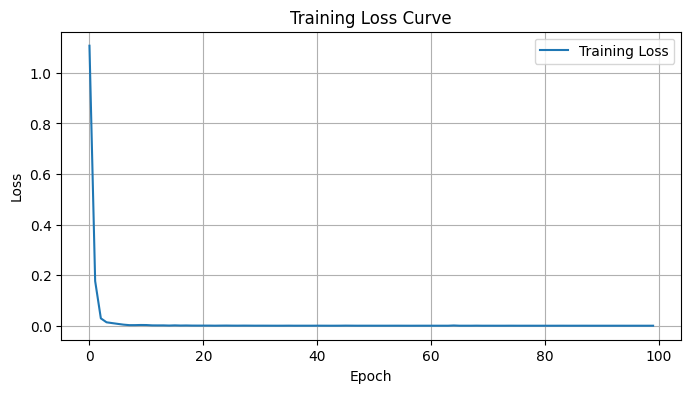

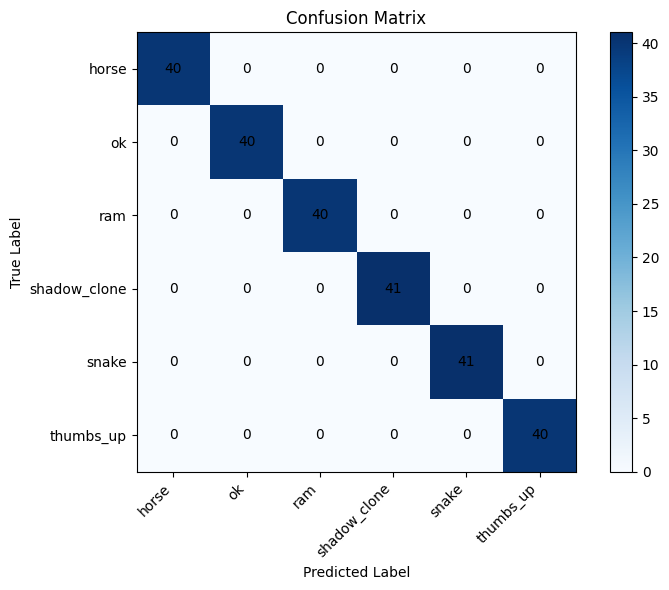

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(num_classes), label_encoder.classes_, rotation=45, ha="right")
plt.yticks(np.arange(num_classes), label_encoder.classes_)

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, conf_matrix[i, j], ha="center", va="center", color="black")

plt.colorbar()
plt.tight_layout()
plt.show()

## 12. Save Model and Metadata

Save the trained model weights and a small configuration file so Phase 6 can rebuild the classifier correctly.

In [12]:
model_path = MODEL_DIR / "gesture_classifier.pth"
model_config_path = MODEL_DIR / "model_config.json"

torch.save(model.state_dict(), model_path)

model_config = {
    "input_size": int(input_size),
    "num_classes": int(num_classes),
    "class_names": label_encoder.classes_.tolist(),
}

with model_config_path.open("w", encoding="utf-8") as file:
    json.dump(model_config, file, indent=2)

print("Saved model to:", model_path)
print("Saved label map to:", label_map_path)
print("Saved scaler to:", scaler_path)
print("Saved model config to:", model_config_path)

Saved model to: C:\Users\kevin\Study\Hand_sign_recognition\models\gesture_classifier.pth
Saved label map to: C:\Users\kevin\Study\Hand_sign_recognition\models\label_map.json
Saved scaler to: C:\Users\kevin\Study\Hand_sign_recognition\models\scaler.pkl
Saved model config to: C:\Users\kevin\Study\Hand_sign_recognition\models\model_config.json
